<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/2_3_Regulatory_Elements_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Gene Regulatory Elements — Promoters, Enhancers, Silencers, Insulators

**Learning objectives**
- Scan a genomic sequence for core promoter motifs (TATA box, CpG islands)
- Score candidate transcription factor binding sites (TFBS) using simple position weight matrices (PWMs)
- Simulate and visualize a chromatin accessibility profile (ATAC-seq-like) across a locus and relate it to predicted regulatory elements
- Model how enhancer–promoter contact frequency decays with genomic distance, and how chromatin looping allows long-range interactions

**Background**

Gene expression is controlled by combinations of *cis*-regulatory elements:
- **Promoters** — sit immediately upstream of the transcription start site (TSS); recruit RNA Pol II and general transcription factors
- **Enhancers** — can act over long genomic distances (kb–Mb), increasing transcription; distance is bridged by **chromatin looping**
- **Silencers** — repress transcription, often by recruiting corepressors or Polycomb complexes
- **Insulators** — block enhancer–promoter communication across their boundary and define **topologically associating domains (TADs)**

Whether any of this matters for a given cell depends on **location** (is the element near the right gene?), **chromatin accessibility** (is the DNA nucleosome-free and reachable?), and **transcription factor binding** (are the right TFs expressed and able to bind?).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

np.random.seed(3)
plt.rcParams['figure.figsize'] = (9,3.5)
print("Environment ready.")


Environment ready.


## Part 1 — Scanning for Core Promoter Motifs

We'll build a synthetic 2 kb genomic window containing a TSS, embed a TATA box and a CpG island, then recover them computationally: a regex scan for the TATA box consensus (`TATAWAWR`), and a sliding-window CpG **observed/expected ratio** scan (the classic Gardiner-Garden & Frommer criteria: GC% > 50, Obs/Exp CpG > 0.6).


In [ ]:
def random_seq(n, gc=0.4, rng=None):
    rng = rng or np.random.default_rng()
    p_gc = gc/2
    p_at = (1-gc)/2
    return ''.join(rng.choice(list('ACGT'), size=n, p=[p_at,p_gc,p_gc,p_at]))

rng = np.random.default_rng(11)
upstream = random_seq(900, gc=0.35, rng=rng)
tata_box = "CTATAAAAGGC"          # embeds TATAAAAG (TATAWAWR-like)
spacer = random_seq(20, gc=0.35, rng=rng)
tss_downstream = random_seq(200, gc=0.35, rng=rng)
cpg_island = ''.join(rng.choice(['CG','GC','CC','GG'], size=180)).replace(' ','')  # GC-rich, CpG-enriched
rest = random_seq(700, gc=0.35, rng=rng)

genomic_window = upstream + tata_box + spacer + tss_downstream + cpg_island + rest
tss_pos = len(upstream) + len(tata_box) + len(spacer)
print(f"Simulated {len(genomic_window)} bp window. TSS placed at position {tss_pos}.")

# --- TATA box scan ---
tata_hits = [m.start() for m in re.finditer(r'TATA[AT]A[AT][AG]', genomic_window)]
print(f"\nTATA-box-like motifs found at position(s): {tata_hits}")
for h in tata_hits:
    dist_to_tss = tss_pos - h
    print(f"  position {h}: {dist_to_tss} bp upstream of the TSS")


Simulated 2191 bp window. TSS placed at position 931.

TATA-box-like motifs found at position(s): [901, 981]
  position 901: 30 bp upstream of the TSS
  position 981: -50 bp upstream of the TSS


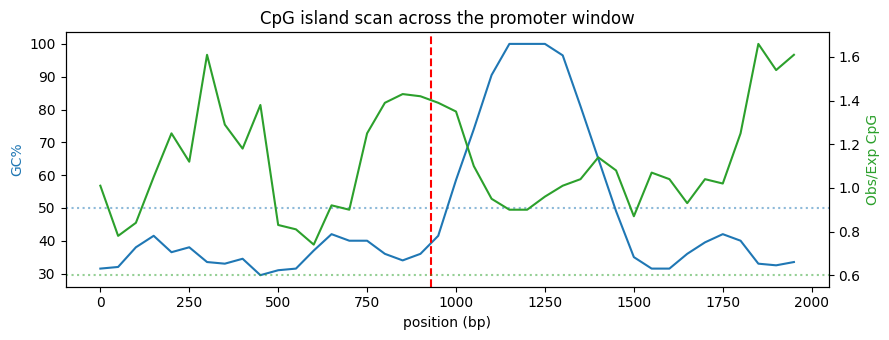

9/40 windows classified as CpG-island-like (GC%>50 and Obs/Exp>0.6).


In [ ]:
def cpg_obs_exp(seq):
    n = len(seq)
    C = seq.count('C'); G = seq.count('G')
    CpG = sum(1 for i in range(n-1) if seq[i:i+2]=='CG')
    if C==0 or G==0: return 0, 0
    gc_pct = 100*(C+G)/n
    obs_exp = (CpG * n) / (C*G) if C*G>0 else 0
    return gc_pct, obs_exp

win, step = 200, 50
results = []
for start in range(0, len(genomic_window)-win, step):
    sub = genomic_window[start:start+win]
    gc_pct, oe = cpg_obs_exp(sub)
    is_cpg_island = (gc_pct > 50) and (oe > 0.6)
    results.append(dict(start=start, gc_pct=round(gc_pct,1), obs_exp_CpG=round(oe,2), is_cpg_island=is_cpg_island))

cpg_df = pd.DataFrame(results)

fig, ax1 = plt.subplots()
ax1.plot(cpg_df['start'], cpg_df['gc_pct'], color='tab:blue', label='GC%')
ax1.axhline(50, color='tab:blue', ls=':', alpha=0.5)
ax1.set_ylabel('GC%', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(cpg_df['start'], cpg_df['obs_exp_CpG'], color='tab:green', label='Obs/Exp CpG')
ax2.axhline(0.6, color='tab:green', ls=':', alpha=0.5)
ax2.set_ylabel('Obs/Exp CpG', color='tab:green')
ax1.axvline(tss_pos, color='red', ls='--', label='TSS')
ax1.set_xlabel('position (bp)')
plt.title('CpG island scan across the promoter window')
plt.tight_layout(); plt.show()

island_windows = cpg_df[cpg_df['is_cpg_island']]
print(f"{len(island_windows)}/{len(cpg_df)} windows classified as CpG-island-like (GC%>50 and Obs/Exp>0.6).")


**Question 1.** Do the TATA box and CpG island signals overlap with where you'd expect a promoter (near the TSS) in this simulation? Real promoters are often *either* TATA-driven (sharp, tissue-specific) *or* CpG-island-driven (broad, housekeeping) — rarely both strongly.


## Part 2 — Scoring Transcription Factor Binding Sites (PWM scan)

We'll use a small illustrative position weight matrix (PWM) for a generic TF motif and scan our window for high-scoring matches, then compare hits inside vs outside the region we've flagged as accessible/near-TSS.


In [ ]:
bases = ['A','C','G','T']
# Toy PWM (8 bp motif) — probabilities per position, illustrative only
pwm_probs = np.array([
 [0.70,0.10,0.10,0.10],  # pos1: strong A preference
 [0.10,0.10,0.70,0.10],  # pos2: strong G
 [0.10,0.60,0.10,0.20],  # pos3
 [0.15,0.15,0.15,0.55],  # pos4
 [0.55,0.15,0.15,0.15],  # pos5
 [0.10,0.10,0.10,0.70],  # pos6
 [0.20,0.20,0.50,0.10],  # pos7
 [0.60,0.15,0.15,0.10],  # pos8
])
pwm = pd.DataFrame(pwm_probs, columns=bases)
background = 0.25
log_odds = np.log2((pwm_probs + 1e-6) / background)

def score_window(seq_window):
    score = 0.0
    for i, b in enumerate(seq_window):
        score += log_odds[i][bases.index(b)]
    return score

motif_len = pwm.shape[0]
max_score = log_odds.max(axis=1).sum()

scan_rows = []
for i in range(len(genomic_window) - motif_len + 1):
    win = genomic_window[i:i+motif_len]
    s = score_window(win)
    scan_rows.append((i, s))

scan_df = pd.DataFrame(scan_rows, columns=['pos','score'])
scan_df['pct_of_max'] = 100*scan_df['score']/max_score
threshold_pct = 80
hits = scan_df[scan_df['pct_of_max'] >= threshold_pct].reset_index(drop=True)
print(f"{len(hits)} TFBS matches at >= {threshold_pct}% of max possible PWM score.\n")
hits['distance_to_TSS'] = hits['pos'] - tss_pos
hits.sort_values('score', ascending=False).head(10)


0 TFBS matches at >= 80% of max possible PWM score.



,pos,score,pct_of_max,distance_to_TSS


**Question 2.** In a real ChIP-seq/motif analysis, a high PWM score alone does not guarantee real *in vivo* binding. What additional evidence (mentioned in Part 3 below) would you want before calling a site "functional"?


## Part 3 — Chromatin Accessibility (ATAC-seq-like) Profile

TF binding in a cell also requires the DNA to be **accessible** (nucleosome-free). We'll simulate an ATAC-seq-style accessibility track — higher near the TSS/promoter and at a synthetic distal enhancer — and overlay our PWM hits to see which ones fall in genuinely accessible chromatin.


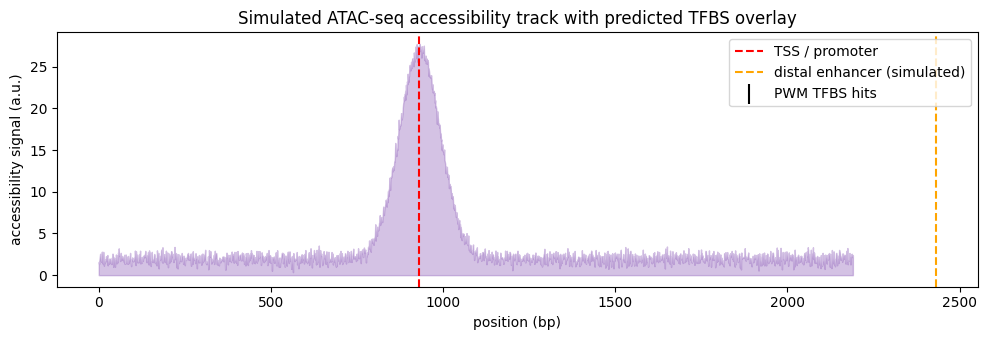

0/0 PWM hits fall in accessible chromatin — these are the better functional candidates.


In [ ]:
x = np.arange(len(genomic_window))
# Base low accessibility + a peak at the promoter + a peak at a distal "enhancer" 1500bp away
accessibility = 2 + 0.5*np.random.default_rng(5).normal(size=len(x))
accessibility += 25 * np.exp(-0.5*((x - tss_pos)/60)**2)                 # promoter peak
enhancer_pos = tss_pos - 1500 if tss_pos-1500 > 0 else tss_pos + 1500
accessibility += 15 * np.exp(-0.5*((x - enhancer_pos)/80)**2)            # distal enhancer peak
accessibility = np.clip(accessibility, 0, None)

plt.figure(figsize=(10,3.5))
plt.fill_between(x, accessibility, color='tab:purple', alpha=0.4)
plt.axvline(tss_pos, color='red', ls='--', label='TSS / promoter')
plt.axvline(enhancer_pos, color='orange', ls='--', label='distal enhancer (simulated)')
plt.scatter(hits['pos'], [2]*len(hits), color='black', marker='|', s=200, label='PWM TFBS hits')
plt.xlabel('position (bp)'); plt.ylabel('accessibility signal (a.u.)')
plt.title('Simulated ATAC-seq accessibility track with predicted TFBS overlay')
plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

accessible_mask = accessibility > 8
hits['accessible'] = hits['pos'].apply(lambda p: bool(accessible_mask[min(p, len(accessible_mask)-1)]))
functional_hits = hits[hits['accessible']]
print(f"{len(functional_hits)}/{len(hits)} PWM hits fall in accessible chromatin — these are the better functional candidates.")


## Part 4 — Enhancer–Promoter Interaction Over Distance (Chromatin Looping)

Enhancers can act on promoters that are far away in linear genomic distance because the intervening chromatin loops out, bringing the two elements into 3D proximity. Hi-C-style contact frequency roughly follows a power-law decay with genomic distance, **except** where an insulator (e.g. a CTCF/cohesin-bound boundary) blocks contact, and **except** where a stable loop (anchored by CTCF sites) creates an enrichment "loop peak" at a specific distance.


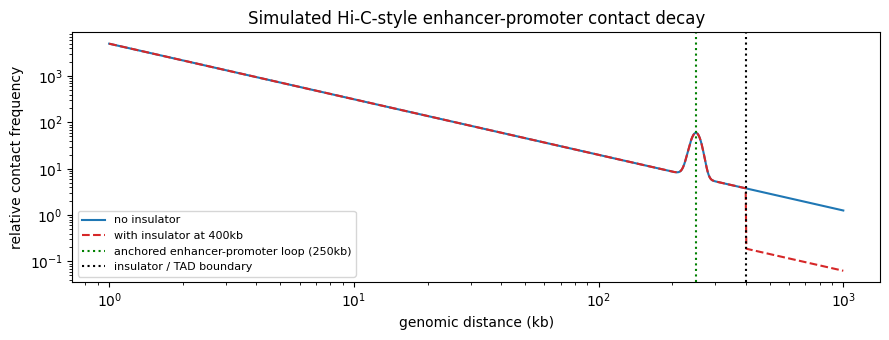

Note the 'loop peak' enrichment at 250kb (a real anchored E-P loop stands out above the smooth decay),
and the sharp drop in contact frequency beyond the insulator at 400kb.


In [ ]:
distance_kb = np.linspace(1, 1000, 400)
# baseline power-law decay of contact frequency with distance
contact_freq = 5000 * distance_kb**-1.2
# add a "loop peak" bump at 250kb (simulating a real anchored enhancer-promoter loop)
contact_freq += 8 * np.exp(-0.5*((distance_kb-250)/12)**2) * 5000*(250**-1.2)
# simulate an insulator boundary at 400kb: sharply reduces contact frequency beyond it
insulator_kb = 400
contact_freq_with_insulator = contact_freq.copy()
contact_freq_with_insulator[distance_kb > insulator_kb] *= 0.05

fig, ax = plt.subplots()
ax.plot(distance_kb, contact_freq, label='no insulator', color='tab:blue')
ax.plot(distance_kb, contact_freq_with_insulator, label='with insulator at 400kb', color='tab:red', ls='--')
ax.axvline(250, color='green', ls=':', label='anchored enhancer-promoter loop (250kb)')
ax.axvline(insulator_kb, color='black', ls=':', label='insulator / TAD boundary')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('genomic distance (kb)'); ax.set_ylabel('relative contact frequency')
ax.set_title('Simulated Hi-C-style enhancer-promoter contact decay')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Note the 'loop peak' enrichment at 250kb (a real anchored E-P loop stands out above the smooth decay),")
print("and the sharp drop in contact frequency beyond the insulator at 400kb.")


**Question 3.** If a candidate enhancer sits 600 kb from its target promoter but on the *other side* of an insulator, what does the model above predict about their functional interaction? What real experimental assay would you use to test this directly?


## Wrap-up Exercises

1. In Part 1, try lowering the simulated background GC content of `upstream`/`rest` — how does that change the number of false-positive CpG-island calls?
2. In Part 2, tighten `threshold_pct` to 90% — how many TFBS hits survive, and are they enriched near the TSS or the enhancer?
3. In Part 3, what fraction of *all* PWM hits genome-wide (not just this window) would you expect to be biologically irrelevant simply because they fall in closed chromatin? Why does that matter when interpreting motif-scanning results?
4. In Part 4, move the insulator to sit *between* the promoter and the 250 kb loop anchor instead of at 400kb, and re-plot. What happens to the loop peak?

---
*This notebook uses simulated/illustrative sequences, PWMs, and contact-frequency curves for teaching purposes. For real analyses, substitute actual genomic sequences (UCSC/Ensembl), real PWMs (JASPAR/HOCOMOCO), real ATAC-seq/DNase-seq tracks, and real Hi-C contact matrices.*
